In [4]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from huggingface_hub import snapshot_download
import pandas as pd
import numpy as np
import seaborn as sns

In [4]:
snapshot_download(
    repo_id="agentica-org/DeepScaleR-1.5B-Preview",
    local_dir="../models/DeepScaleR-1.5B-Preview"
)

Fetching 11 files: 100%|██████████| 11/11 [01:09<00:00,  6.29s/it]


'/home4/s6019595/nlp/models/DeepScaleR-1.5B-Preview'

In [6]:
# Login using e.g. `huggingface-cli login` to access this dataset
df = pd.read_csv("hf://datasets/di-zhang-fdu/AIME_1983_2024/AIME_Dataset_1983_2024.csv")

In [ ]:
df.to_parquet("dataset_aime.parquet")

In [7]:
df

,ID,Year,Problem Number,Question,Answer,Part
0,1983-1,1983,1,"Let $x$ , $y$ and $z$ all exceed $1$ and let $...",60,NaN
1,1983-2,1983,2,"Let $f(x)=|x-p|+|x-15|+|x-p-15|$ , where $0 < ...",15,NaN
2,1983-3,1983,3,What is the product of the real roots of the e...,20,NaN
3,1983-4,1983,4,A machine-shop cutting tool has the shape of a...,26,NaN
4,1983-5,1983,5,Suppose that the sum of the squares of two com...,4,NaN
...,...,...,...,...,...,...
928,2024-II-11,2024,11,Find the number of triples of nonnegative inte...,601,II
929,2024-II-12,2024,12,"Let $O(0,0),A(\tfrac{1}{2},0),$ and $B(0,\tfra...",23,II
930,2024-II-13,2024,13,Let $\omega\neq 1$ be a 13th root of unity. Fi...,321,II
931,2024-II-14,2024,14,Let $b \geq 2$ be an integer. Call a positive ...,211,II


In [3]:
math_dataset_df = pd.read_parquet("hf://datasets/qwedsacf/competition_math/data/train-00000-of-00001-7320a6f3aba8ebd2.parquet")
#math_dataset_df.to_parquet("dataset.parquet")
math_dataset_df


,problem,level,type,solution
0,"Let \[f(x) = \left\{\n\begin{array}{cl} ax+3, ...",Level 5,Algebra,"For the piecewise function to be continuous, t..."
1,A rectangular band formation is a formation wi...,Level 5,Algebra,Let $x$ be the number of band members in each ...
2,What is the degree of the polynomial $(4 +5x^3...,Level 3,Algebra,This polynomial is not written in standard for...
3,Evaluate $\left\lceil3\left(6-\frac12\right)\r...,Level 3,Algebra,"Firstly, $3\left(6-\frac12\right)=18-1-\frac12..."
4,Sam is hired for a 20-day period. On days that...,Level 3,Algebra,Call $x$ the number of days Sam works and $y$ ...
...,...,...,...,...
12495,If $\sin x + \cos x = \frac{1}{5}$ and $0 < x ...,Level 5,Precalculus,"From the given equation, $\cos x = \frac{1}{5}..."
12496,The matrix for projecting onto a certain plane...,Level 5,Precalculus,Since $\begin{pmatrix} a \\ b \\ c \end{pmatri...
12497,"Let $\mathbf{a},$ $\mathbf{b},$ and $\mathbf{c...",Level 4,Precalculus,Since $\mathbf{a} + \mathbf{b} + \mathbf{c} = ...
12498,Find the smallest positive integer solution to...,Level 5,Precalculus,"By the tangent addition formula,\n\begin{align..."


In [ ]:
snapshot_download(
    repo_id="l3lab/L1-Qwen-1.5B-Exact",
    local_dir="L1-Qwen-1.5B-Exact"
)
snapshot_download(
    repo_id="deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B",
    local_dir="./DeepSeek-R1-Distill-Qwen-1.5B"
)

Fetching 10 files: 100%|██████████| 10/10 [00:58<00:00,  5.83s/it]


'/home4/s6019595/nlp/L1-Qwen-1.5B-Exact'

In [2]:
path_base = "./models/DeepSeek-R1-Distill-Qwen-1.5B"
model_base = AutoModelForCausalLM.from_pretrained(
    path_base,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)
tokenizer_base = AutoTokenizer.from_pretrained(path_base)

Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.


In [4]:
model_path = "./models/L1-Qwen-1.5B-Exact"
model_LCPO = AutoModelForCausalLM.from_pretrained(
    model_path,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained(model_path)

Loading checkpoint shards: 100%|██████████| 2/2 [00:02<00:00,  1.21s/it]


In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [6]:
prompt = "Solve: What is 23 * 19? Think for 300 tokens."
inputs = tokenizer(prompt, return_tensors="pt").to(device)

outputs_LCPO = model_LCPO.generate(
    **inputs,
    max_new_tokens=600,
    temperature=0.7,
    do_sample=True
)

# Count tokens
prompt_len = inputs.input_ids.shape[1]
total_len = outputs_LCPO[0].shape[0]
generated_len = total_len - prompt_len

print("\n=== LCPO Model Output ===")
print(f"Prompt tokens: {prompt_len}")
print(f"Generated tokens: {generated_len}")
print(f"Total sequence length: {total_len}")
print(tokenizer.decode(outputs_LCPO[0], skip_special_tokens=True))


Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.



=== LCPO Model Output ===
Prompt tokens: 22
Generated tokens: 106
Total sequence length: 128
Solve: What is 23 * 19? Think for 300 tokens.]
The answer is \boxed{437}.
</think>

To find the product of 23 and 19, we can use the distributive property:

\[
23 \times 19 = 23 \times (20 - 1) = 23 \times 20 - 23 \times 1 = 460 - 23 = 437
\]

Thus, the final answer is \(\boxed{437}\).


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

def run_phase(prompt, target_tokens, max_steps=2000, tolerance=30):
    """Generate until target length is reached (± tolerance) or EOS."""
    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model_LCPO(**inputs)
    past_key_values = outputs.past_key_values
    generated = inputs.input_ids

    print(f"\n=== Phase Start ===")
    print(f"Prompt length: {inputs.input_ids.shape[1]} tokens")
    print(f"Target reasoning tokens: {target_tokens}")

    for step in range(1, max_steps + 1):
        with torch.no_grad():
            out = model_LCPO(
                input_ids=generated[:, -1:], 
                past_key_values=past_key_values,
                use_cache=True
            )
        logits = out.logits[:, -1, :]
        past_key_values = out.past_key_values
        next_token = torch.argmax(logits, dim=-1)
        generated = torch.cat([generated, next_token.unsqueeze(-1)], dim=-1)

        # Stop if EOS
        if next_token.item() == tokenizer.eos_token_id:
            print(f"Stopped early at step {step}: EOS emitted")
            break

        # Check length vs target
        actual = generated.shape[1] - inputs.input_ids.shape[1]
        if abs(actual - target_tokens) <= tolerance:
            print(f"Stopped at step {step}: Target ~{target_tokens} reached (actual {actual})")
            break

    total_generated = generated.shape[1] - inputs.input_ids.shape[1]
    print(f"\n=== Phase End ===")
    print(f"Expected: ~{target_tokens} | Actual generated: {total_generated}")
    print(tokenizer.decode(generated[0], skip_special_tokens=True)[:600], "...\n")

    return tokenizer.decode(generated[0], skip_special_tokens=True)

# --- Phase 1: Think for 300 ---
phase1_prompt = "Solve: What is 23 * 19 * 30?, Think for 300 tokens."
phase1_output = run_phase(phase1_prompt, target_tokens=300)

# --- Phase 2: Edit to 500 ---
phase2_prompt = phase1_output.replace("Think for 300", "Think for 500")
phase2_output = run_phase(phase2_prompt, target_tokens=500)



=== Phase Start ===
Prompt length: 26 tokens
Target reasoning tokens: 300
Stopped at step 270: Target ~300 reached (actual 270)

=== Phase End ===
Expected: ~300 | Actual generated: 270
Solve: What is 23 * 19 * 30?, Think for 300 tokens.<think>
Okay, so I need to solve 23 * 19 * 30. Hmm, where do I start? Maybe I can break it down step by step. First, I'll multiply 23 and 19. Let me see, 23 times 20 is 460, but since it's 19, that's one less, so 460 - 23 = 437. So, 23 * 19 = 437. Now, I need to multiply that result by 30. So, 437 * 30. Hmm, multiplying by 30 is the same as multiplying by 3 and then by 10. So, 437 * 3 = 1,311, and then adding a zero makes it 13,110. So, the final answer should be 13,110. I think that's it!
</think>

The solution to 23 * 19 * 30 is calculated a ...


=== Phase Start ===
Prompt length: 296 tokens
Target reasoning tokens: 500
Stopped early at step 10: EOS emitted

=== Phase End ===
Expected: ~500 | Actual generated: 10
Solve: What is 23 * 19 * 30?, Think 

In [29]:
def run_phase(target_tokens: int):
    """Run LCPO with 'Think for N tokens' and count only <think>...</think> tokens."""
    # Construct the prompt dynamically
    prompt = f"Solve: What is 23 * 19 * 30?, Think for {target_tokens} tokens."
    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model_LCPO(**inputs)
    past_key_values = outputs.past_key_values
    generated = inputs.input_ids

    print(f"\n=== Phase Start ===")
    print(f"Prompt length: {inputs.input_ids.shape[1]} tokens")
    print(f"Target reasoning tokens: {target_tokens}")

    # Generate until EOS
    while True:
        with torch.no_grad():
            out = model_LCPO(
                input_ids=generated[:, -1:], 
                past_key_values=past_key_values,
                use_cache=True
            )
        logits = out.logits[:, -1, :]
        past_key_values = out.past_key_values
        next_token = torch.argmax(logits, dim=-1)
        generated = torch.cat([generated, next_token.unsqueeze(-1)], dim=-1)

        # EOS check
        if next_token.item() == tokenizer.eos_token_id:
            print("Stopped: EOS emitted")
            break

    # Decode and extract <think>...</think>
    full_text = tokenizer.decode(generated[0], skip_special_tokens=True)
    think_start = full_text.find("<think>")
    think_end = full_text.find("</think>")

    if think_start != -1 and think_end != -1:
        think_content = full_text[think_start + len("<think>"):think_end]
        think_tokens = tokenizer(think_content, return_tensors="pt").input_ids.shape[1]
    else:
        think_content = ""
        think_tokens = 0

    print(f"\n=== Phase End ===")
    print(f"Expected reasoning tokens: ~{target_tokens}")
    print(f"Actual reasoning tokens: {think_tokens}")
    print(f"Preview of reasoning:\n{think_content[:600]}...\n")

    return full_text, think_tokens


# --- Run Phase 1 (300 tokens) ---
phase1_output, phase1_count = run_phase(300)

# --- Run Phase 2 (500 tokens) ---
phase2_output, phase2_count = run_phase(500)



=== Phase Start ===
Prompt length: 26 tokens
Target reasoning tokens: 300
Stopped: EOS emitted

=== Phase End ===
Expected reasoning tokens: ~300
Actual reasoning tokens: 210
Preview of reasoning:

Okay, so I need to solve 23 * 19 * 30. Hmm, where do I start? Maybe I can break it down step by step. First, I'll multiply 23 and 19. Let me see, 23 times 20 is 460, but since it's 19, that's one less, so 460 - 23 = 437. So, 23 * 19 = 437. Now, I need to multiply that result by 30. So, 437 * 30. Hmm, multiplying by 30 is the same as multiplying by 3 and then by 10. So, 437 * 3 = 1,311, and then adding a zero makes it 13,110. So, the final answer should be 13,110. I think that's it!
...


=== Phase Start ===
Prompt length: 26 tokens
Target reasoning tokens: 500
Stopped: EOS emitted

=== Phase End ===
Expected reasoning tokens: ~500
Actual reasoning tokens: 451
Preview of reasoning:

Okay, so I need to solve 23 * 19 * 30. Hmm, let me think about the best way to approach this. I know that mult

In [1]:
from pathlib import Path
import pandas as pd

data_dir = Path("..") / "generated_aime"

csv_files = [f for f in data_dir.iterdir() if f.suffix == ".csv"]

df = pd.concat((pd.read_csv(f) for f in csv_files), ignore_index=True)

print(f"Loaded {len(csv_files)} CSV files, resulting in {len(df)} rows.")
df.head()


Loaded 1130 CSV files, resulting in 4520 rows.


,question_id,prompt,expected_answer,generated_think_text,generated_text,target_think_tokens,generated_think_tokens,latency_sec,is_correct
0,1983-1,"Let $x$ , $y$ and $z$ all exceed $1$ and let $...",60,"Okay, so I have this problem with logarithms. ...","Let $x$ , $y$ and $z$ all exceed $1$ and let $...",100,377,37.736352,False
1,1983-1,"Let $x$ , $y$ and $z$ all exceed $1$ and let $...",60,"Okay, so I have this problem with logarithms, ...","Let $x$ , $y$ and $z$ all exceed $1$ and let $...",366,554,37.736352,False
2,1983-1,"Let $x$ , $y$ and $z$ all exceed $1$ and let $...",60,"Okay, so I have this problem here with logarit...","Let $x$ , $y$ and $z$ all exceed $1$ and let $...",633,625,37.736352,True
3,1983-1,"Let $x$ , $y$ and $z$ all exceed $1$ and let $...",60,"Okay, so I have this problem here with logarit...","Let $x$ , $y$ and $z$ all exceed $1$ and let $...",900,1604,37.736352,True
4,1983-1,"Let $x$ , $y$ and $z$ all exceed $1$ and let $...",60,"Okay, so I have this problem here with logarit...","Let $x$ , $y$ and $z$ all exceed $1$ and let $...",1166,1419,51.523425,False


In [4]:
df["question_id"].unique().size
accuracy = df["is_correct"].mean() * 100
accuracy

np.float64(32.83185840707964)

Loaded 1675 CSV files
Unique questions: 670
Correct: 396
Overall accuracy: 31.40%


/tmp/ipykernel_779853/2929473244.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  acc_by_bin = df.groupby("token_bin")["is_correct"].mean() * 100


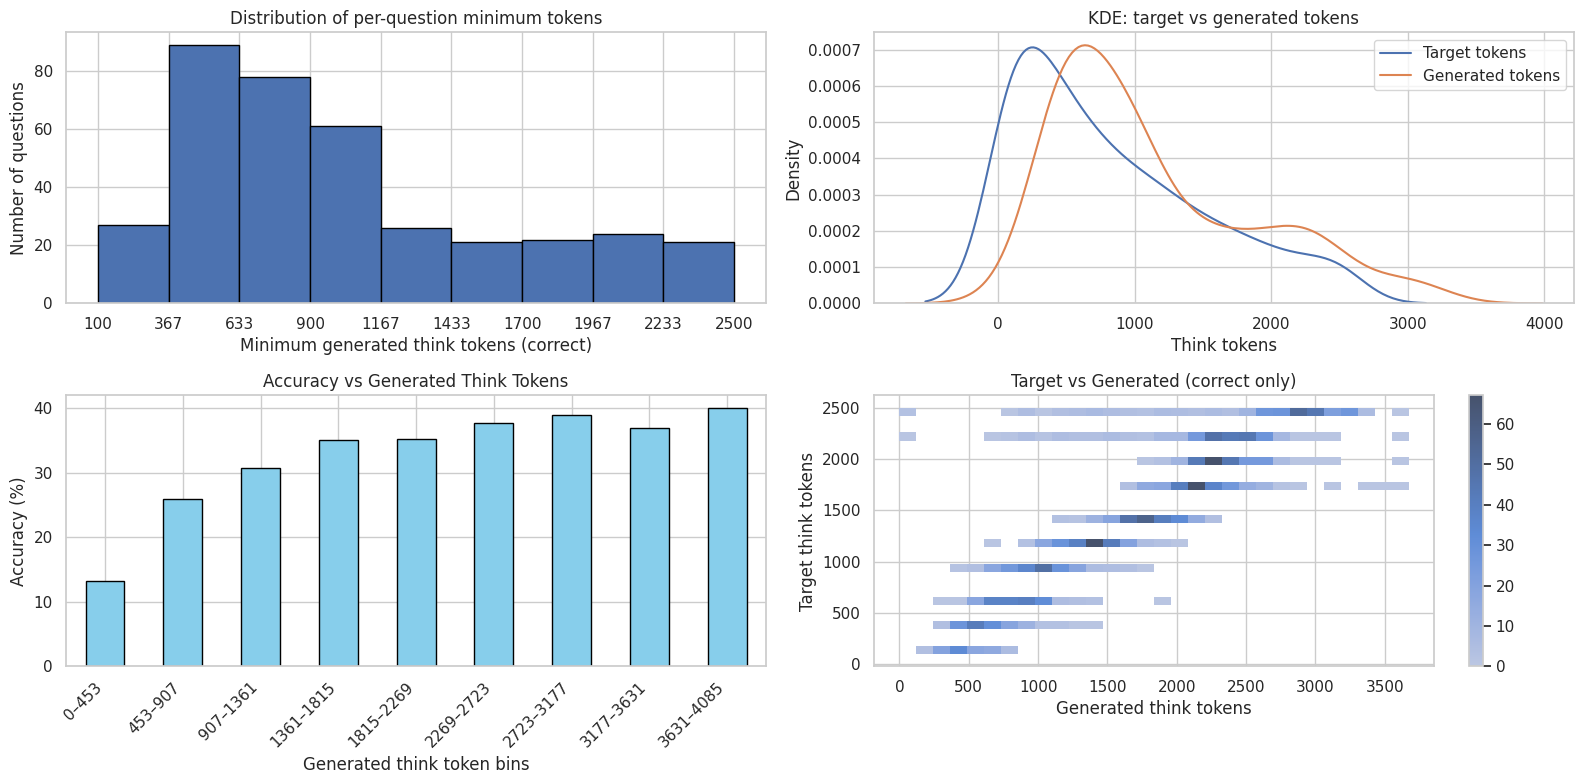

In [5]:
sns.set(style="whitegrid")
import matplotlib.pyplot as plt
# === LOAD DATA ===
data_dir = Path("..") / "generated_aime"
csv_files = [f for f in data_dir.iterdir() if f.suffix == ".csv"]
df = pd.concat((pd.read_csv(f) for f in csv_files), ignore_index=True)

# === BASIC STATS ===
print(f"Loaded {len(csv_files)} CSV files")
print(f"Unique questions: {df['question_id'].nunique()}")
num = df.loc[df["is_correct"], "question_id"].nunique()
print(f"Correct: {num}")
print(f"Overall accuracy: {df['is_correct'].mean() * 100:.2f}%")

# === PREP ===
tokens = np.round(np.linspace(100, 2500, num=10, endpoint=True)).astype(int)
correct = df[df["is_correct"]]
incorrect = df[~df["is_correct"]]

# === PER-QUESTION MIN TOKENS (CORRECT ONLY) ===
min_tokens = correct.groupby("question_id")["generated_think_tokens"].min().sort_values()
min_tokens_target = correct.groupby("question_id")["target_think_tokens"].min()

# === COMBINED PLOTTING ===
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.ravel()

# (1) Histogram of per-question minimum tokens
axes[0].hist(
    min_tokens,
    bins=np.append(tokens - 0.5, tokens[-1] + 0.5),
    edgecolor="black",
)
axes[0].set_xticks(tokens)
axes[0].set_xlabel("Minimum generated think tokens (correct)")
axes[0].set_ylabel("Number of questions")
axes[0].set_title("Distribution of per-question minimum tokens")

# (2) KDE: Target vs Generated
sns.kdeplot(min_tokens_target, ax=axes[1], label="Target tokens")
sns.kdeplot(min_tokens, ax=axes[1], label="Generated tokens")
axes[1].set_xlabel("Think tokens")
axes[1].set_ylabel("Density")
axes[1].set_title("KDE: target vs generated tokens")
axes[1].legend()

# (3) Accuracy vs generated tokens (fix negative bins)
bin_edges = np.linspace(0, df["generated_think_tokens"].max(), 10)
df["token_bin"] = pd.cut(df["generated_think_tokens"], bins=bin_edges, include_lowest=True)
acc_by_bin = df.groupby("token_bin")["is_correct"].mean() * 100

acc_by_bin.plot(kind="bar", ax=axes[2], edgecolor="black", color="skyblue")
axes[2].set_ylabel("Accuracy (%)")
axes[2].set_xlabel("Generated think token bins")
axes[2].set_title("Accuracy vs Generated Think Tokens")
axes[2].set_xticklabels(
    [f"{int(b.left)}–{int(b.right)}" for b in acc_by_bin.index],
    rotation=45,
    ha="right"
)

# (4) Joint distribution target vs generated (correct only)
sns.histplot(
    correct,
    x="generated_think_tokens",
    y="target_think_tokens",
    bins=30,
    pmax=0.9,
    cbar=True,
    ax=axes[3],
)
axes[3].set_xlabel("Generated think tokens")
axes[3].set_ylabel("Target think tokens")
axes[3].set_title("Target vs Generated (correct only)")

plt.tight_layout()
plt.show()
